# CNCpp Python Usage Example

Create a machine from `machine.toml`, load `test.g` as a program, and plot the normalized block coordinate `lambda` against total program time.

In [1]:
from pathlib import Path
import sys

current_dir = Path.cwd().resolve()
repo_root = next(
    path
    for path in (current_dir, *current_dir.parents)
    if (path / "machine.toml").exists() and (path / "test.g").exists()
)

build_python = repo_root / "build" / "python"
if build_python.exists():
    sys.path.insert(0, str(build_python))

import cncpp

machine_path = repo_root / "machine.toml"
program_path = repo_root / "test.g"

machine_path, program_path

(PosixPath('/Users/p4010/Develop/cncpp_26/machine.toml'),
 PosixPath('/Users/p4010/Develop/cncpp_26/test.g'))

In [2]:
machine = cncpp.Machine(str(machine_path))
program = cncpp.Program(str(program_path), machine)

machine.summary(), program.summary()

({'A': 10.0,
  'tq': 0.001,
  'fmax': 1000.0,
  'error': 0.0,
  'max_error': 0.005,
  'zero': (0.0, 0.0, 0.0),
  'offset': (0.0, 0.0, 0.0),
  'setpoint': None,
  'position': None},
 [{'line': 'N10 G00 X100 Y100 Z100',
   'n': 10,
   'parsed': True,
   'type_code': 0,
   'type': 'RAPID',
   'tool': 0,
   'feedrate': 0.0,
   'arc_feedrate': 0.0,
   'spindle': 0.0,
   'length': 173.20508075688772,
   'dt': 0.0,
   'm': 0,
   'r': 0.0},
  {'line': 'N20 G01 Z50 F1000 S5000 M03',
   'n': 20,
   'parsed': True,
   'type_code': 1,
   'type': 'LINE',
   'tool': 0,
   'feedrate': 1000.0,
   'arc_feedrate': 1000.0,
   'spindle': 5000.0,
   'length': 50.0,
   'dt': 4.667,
   'm': 3,
   'r': 0.0},
  {'line': 'N30 G01 X150',
   'n': 30,
   'parsed': True,
   'type_code': 1,
   'type': 'LINE',
   'tool': 0,
   'feedrate': 1000.0,
   'arc_feedrate': 1000.0,
   'spindle': 5000.0,
   'length': 50.0,
   'dt': 4.667,
   'm': 0,
   'r': 0.0},
  {'line': 'N40 G01 Y150',
   'n': 40,
   'parsed': True,
   'ty

In [3]:
samples = program.walk()

times = [row["time"] for row in samples]
lambda_values = [row["lambda"] for row in samples]

len(samples), times[:3], lambda_values[:3]

(18913,
 [0.0, 0.001, 0.002],
 [0.0, 9.998889012331963e-08, 3.999555604932785e-07])

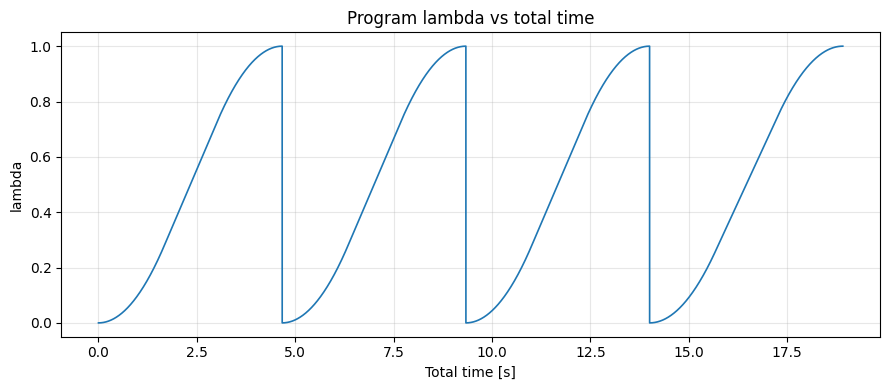

In [4]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    from IPython.display import SVG, display

    width, height, margin = 900, 420, 55
    x_min, x_max = min(times), max(times)
    y_min, y_max = 0.0, 1.0
    stride = max(1, len(times) // 2000)
    plot_times = times[::stride]
    plot_lambdas = lambda_values[::stride]

    def scale_x(value):
        return margin + (value - x_min) / (x_max - x_min) * (width - 2 * margin)

    def scale_y(value):
        return height - margin - (value - y_min) / (y_max - y_min) * (height - 2 * margin)

    points = " ".join(
        f"{scale_x(t):.2f},{scale_y(lam):.2f}"
        for t, lam in zip(plot_times, plot_lambdas)
    )
    svg = f"""
    <svg width="{width}" height="{height}" viewBox="0 0 {width} {height}" xmlns="http://www.w3.org/2000/svg">
      <rect width="100%" height="100%" fill="white"/>
      <line x1="{margin}" y1="{height - margin}" x2="{width - margin}" y2="{height - margin}" stroke="#222"/>
      <line x1="{margin}" y1="{margin}" x2="{margin}" y2="{height - margin}" stroke="#222"/>
      <polyline points="{points}" fill="none" stroke="#1f77b4" stroke-width="1.4"/>
      <text x="{width / 2}" y="{height - 12}" text-anchor="middle" font-size="14">Total time [s]</text>
      <text x="18" y="{height / 2}" text-anchor="middle" font-size="14" transform="rotate(-90 18 {height / 2})">lambda</text>
      <text x="{width / 2}" y="28" text-anchor="middle" font-size="16">Program lambda vs total time</text>
    </svg>
    """
    display(SVG(svg))
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(times, lambda_values, linewidth=1.2)
    ax.set_xlabel("Total time [s]")
    ax.set_ylabel("lambda")
    ax.set_title("Program lambda vs total time")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()